# Walkthrough: finding the knowledge a BRD doesn't write down

Johann James

This notebook walks through the prototype one step at a time, on the sample regulation and BRD in `data/`. Every cell has already been run, so you can read the outputs here on GitHub without installing anything. To run it yourself: `pip install -r requirements.txt jupyter`, then open this notebook.

In [1]:
from IPython.display import Markdown, Image, display
from regkg.parse import parse_regulation, parse_brd
from regkg.anchors import extract_anchors
from regkg.coverage import align
from regkg.semantic import run_semantic, REQ_PROMPT
from regkg.knowledge import build_needs, requirement_profile
from regkg.evaluate import evaluate

def table(rows, cols):
    head = "| " + " | ".join(cols) + " |\n|" + "---|" * len(cols) + "\n"
    body = "\n".join("| " + " | ".join(str(r[c]).replace("|", "/") for c in cols) + " |" for r in rows)
    display(Markdown(head + body))

clauses = parse_regulation("data/regulation.md")
brd = parse_brd("data/brd.md")
print(f"{len(clauses)} regulation clauses, {len(brd.requirements)} BRD requirements, {len(brd.glossary)} glossary terms")

13 regulation clauses, 11 BRD requirements, 7 glossary terms


## 1. The inputs

A made-up large-exposures regulation and a BRD I wrote from it. Here is one clause and the requirement that implements it. Notice how much more specific the BRD is.

In [2]:
reg = {c.id: c for c in clauses}
req = {r.id: r for r in brd.requirements}
display(Markdown(f"**Regulation §2.2:** {reg['§2.2'].text}\n\n**BRD BR-04:** {req['BR-04'].text}"))

**Regulation §2.2:** "Group of connected counterparties" means two or more natural or legal persons where one of them has, directly or indirectly, control over the other or others; or between whom there is economic interdependence such that financial problems of one would likely result in repayment difficulties for the others.

**BRD BR-04:** Counterparties shall be grouped using the GROUP_ID field in the CRM customer master. Where GROUP_ID is null, customers sharing the same PAN or the same registered address shall be treated as a group of connected counterparties.

The regulation talks about control and economic interdependence. The BRD talks about a `GROUP_ID` field, a CRM system, and a fallback rule using PAN or registered address. None of that is in the regulation. Where did it come from?

## 2. Knowledge anchors (rules only, no LLM)

For each requirement, pattern rules pull out the concrete details, and each one is checked against the regulation and the BRD glossary. `NONE` means neither document explains it.

In [3]:
anchors = {r.id: extract_anchors(r, clauses, brd.glossary) for r in brd.requirements}
for rid in ["BR-03", "BR-04"]:
    display(Markdown(f"**{rid}**"))
    table([{"detail": a.text[:70], "kind": a.kind, "found in": a.grounding, "where": a.grounded_ref}
           for a in anchors[rid]], ["detail", "kind", "found in", "where"])

**BR-03**

| detail | kind | found in | where |
|---|---|---|---|
| Credit Risk Policy v4.2, Annexure 3 | DOC_REF | NONE |  |
| SANCTION_LIMIT | DATA_FIELD | NONE |  |
| TF_CONTINGENT | DATA_FIELD | NONE |  |
| TF | ACRONYM | BRD | glossary:TF |
| CCF | ACRONYM | REG | §2.1 |

**BR-04**

| detail | kind | found in | where |
|---|---|---|---|
| GROUP_ID | DATA_FIELD | NONE |  |
| CRM | ACRONYM | BRD | glossary:CRM |
| PAN | ACRONYM | BRD | glossary:PAN |
| Where GROUP_ID is null, customers sharing the same PAN or the same reg | DECISION | NONE |  |

Two things worth noticing. `CCF` is traced back to the regulation because its initials match "credit conversion factors" in §2.1. And the fallback sentence in BR-04 is caught as a *decision* because of the phrase "where GROUP_ID is null".

## 3. Coverage: which clauses does nobody implement?

In [4]:
links, uncovered = align(clauses, brd.requirements, brd.glossary)
print(f"{len(links)} requirement-to-clause links found by word overlap")
print("Obligations with no implementing requirement:", uncovered)
print(reg[uncovered[0]].text)

12 requirement-to-clause links found by word overlap
Obligations with no implementing requirement: ['§7.1']
Banks shall maintain documented data lineage for all reported figures.


## 4. The LLM step and the regulation-only twin

Rules only see surface details. For each requirement, the LLM gets the regulation, the glossary and the requirement, and is asked to (1) say how the requirement relates to each clause, (2) rewrite it using **only** the regulation, and (3) list the facts or decisions needed to get from that rewrite to the real text. Here's the start of the prompt:

In [5]:
print(REQ_PROMPT[:900] + "\n...")

You are analysing how a Business Requirements Document (BRD) was derived from a regulation.

REGULATION (clause id: text):
{regulation}

BRD GLOSSARY:
{glossary}

BRD REQUIREMENT {req_id}: {req_text}

Do three things.
1. ALIGNMENT: list the regulation clauses this requirement implements. For each, give a relation:
   "entailed" (follows directly), "refines" (makes a regulatory concept more specific),
   "extends" (adds something the regulation does not mention), or "contradicts" (conflicts in any detail).
2. TWIN: rewrite the requirement as a careful analyst would write it using ONLY the regulation,
   with no knowledge of this bank's systems, products or past decisions.
3. PREMISES: list every fact or decision needed to get from the clauses to the ACTUAL requirement
   that is not in the twin. Be specific (name the field, number, or decision), never generic.
   For each premise give kno
...


I didn't have an API key, so the answers below were produced by hand from this prompt and saved in `data/llm_cache.json`. With a key, `python run.py --llm anthropic` sends the real prompts.

Here's why this step matters. BR-05 looks perfectly clean to the rules, since every detail traces to a source. But compare it with its twin:

In [6]:
semantic = run_semantic(clauses, brd, mode="cache")
s = semantic["requirements"]["BR-05"]
display(Markdown(f"**Regulation-only twin:** {s['twin']}\n\n**Actual BRD:** {req['BR-05'].text}\n\n"
                 f"**Relation found:** {s['alignment'][0]['clause']} {s['alignment'][0]['relation']}\n\n"
                 f"**Missing premise:** {s['premises'][0]['premise']}"))
print("Unsourced details the rules found in BR-05:", [a.text for a in anchors["BR-05"] if a.grounding == "NONE"])

**Regulation-only twin:** The eligible capital base shall be the Tier 1 capital reported in the most recent capital adequacy return.

**Actual BRD:** The eligible capital base shall be the Tier 1 capital figure from the CAR return for the same reporting quarter.

**Relation found:** §2.3 contradicts

**Missing premise:** Timing choice: BRD uses the same reporting quarter's CAR return, while the regulation says most recent; the same-quarter return may not be filed when LE-1 is due.

Unsourced details the rules found in BR-05: []


## 5. Gaps, levels and likely sources

Rules and LLM findings are merged into *knowledge needs*. Each gets a type, a level and a likely source:

- **P2**: names something we don't have (a table, a document). Someone needs to fetch it.
- **P3**: a number or decision with no source or reason. Someone needs to be asked.

In [7]:
needs = build_needs(brd.requirements, anchors, semantic, uncovered, clauses)
table([{"gap": k.id, "req": k.req, "type": k.knowledge_type.lower(), "level": k.level,
         "likely source": k.sources[0], "question": k.sme_question[:90]}
       for k in needs if k.req in ("BR-01", "BR-03", "BR-04")],
      ["gap", "req", "type", "level", "likely source", "question"])
print(f"{len(needs)} gaps in total")

| gap | req | type | level | likely source | question |
|---|---|---|---|---|---|
| KN-01 | BR-01 | operational_practice | P3 | Regulatory calendar / submission SOP | Is T+12 business days intended as an internal buffer? It can land after the 15 calendar da |
| KN-03 | BR-03 | referenced_document | P2 | Policy repository / document management system | Can we get Credit Risk Policy v4.2 Annexure 3, and confirm it matches the Standardised App |
| KN-04 | BR-03 | data_lineage | P2 | TF data dictionary (or enterprise metadata catalog) | Where are TF_CONTINGENT and SANCTION_LIMIT defined, and do they cover all off-balance shee |
| KN-05 | BR-04 | reference_data | P2 | Reference data / code list master | Who maintains GROUP_ID, using what criteria, and does it reflect control as defined in the |
| KN-06 | BR-04 | regulatory_interpretation | P3 | Compliance interpretation memos | What is the basis for treating a shared registered address as connection? Was this approve |
| KN-14 | BR-03 | calculation_method | P3 | Risk methodology documents | Why is the CCF applied to the sanctioned limit rather than the outstanding or utilised amo |

24 gaps in total


In [8]:
profile = requirement_profile(brd.requirements, anchors, needs, semantic)
table(profile, ["req", "title", "level", "anchors", "reg_grounded", "brd_grounded", "ungrounded", "needs"])

| req | title | level | anchors | reg_grounded | brd_grounded | ungrounded | needs |
|---|---|---|---|---|---|---|---|
| BR-01 | Frequency and submission | P3 | 2 | 1 | 0 | 1 | 1 |
| BR-02 | Funded exposure | P3 | 4 | 0 | 1 | 3 | 2 |
| BR-03 | Non-funded exposure | P3 | 5 | 1 | 1 | 3 | 3 |
| BR-04 | Grouping of counterparties | P3 | 4 | 0 | 2 | 2 | 2 |
| BR-05 | Eligible capital base | P3 | 2 | 1 | 1 | 0 | 1 |
| BR-06 | Reporting threshold | P0 | 2 | 2 | 0 | 0 | 0 |
| BR-07 | Exempt exposures | P2 | 3 | 0 | 0 | 3 | 1 |
| BR-08 | Collateral | P3 | 2 | 0 | 1 | 1 | 3 |
| BR-09 | Interbank exposures | P2 | 3 | 0 | 0 | 3 | 2 |
| BR-10 | Output format | P3 | 3 | 1 | 0 | 2 | 1 |
| BR-11 | Reconciliation | P3 | 3 | 0 | 1 | 2 | 2 |

Only one requirement (BR-06) traces fully to the regulation.

## 6. How well did it do?

18 gaps were planted in the BRD before anything was run (`data/ground_truth.json`). Here's the comparison with and without the LLM step.

In [9]:
det_needs = build_needs(brd.requirements, anchors, None, uncovered, clauses)
for name, ns in [("Rules only", det_needs), ("Rules + LLM", needs)]:
    e = evaluate(ns, "data/ground_truth.json")
    print(f"{name:12s} found {e['found']}/{e['total']}  raised {e['needs']}  matched {e['precision']:.0%}  missed {e['missed']}")

Rules only   found 13/18  raised 13  matched 100%  missed ['G03', 'G05', 'G09', 'G12', 'G18']
Rules + LLM  found 18/18  raised 24  matched 75%  missed []


The rules found every gap visible in the text, with no false alarms. The five they missed are the ones only visible through meaning. With the LLM step, the extra flags are the same gaps seen from the regulation's side, plus two real gaps I hadn't planted.

**Caveat:** I wrote the regulation, the BRD and the answer key, and produced the LLM answers by hand, so this is not an independent test.

## 7. The graph

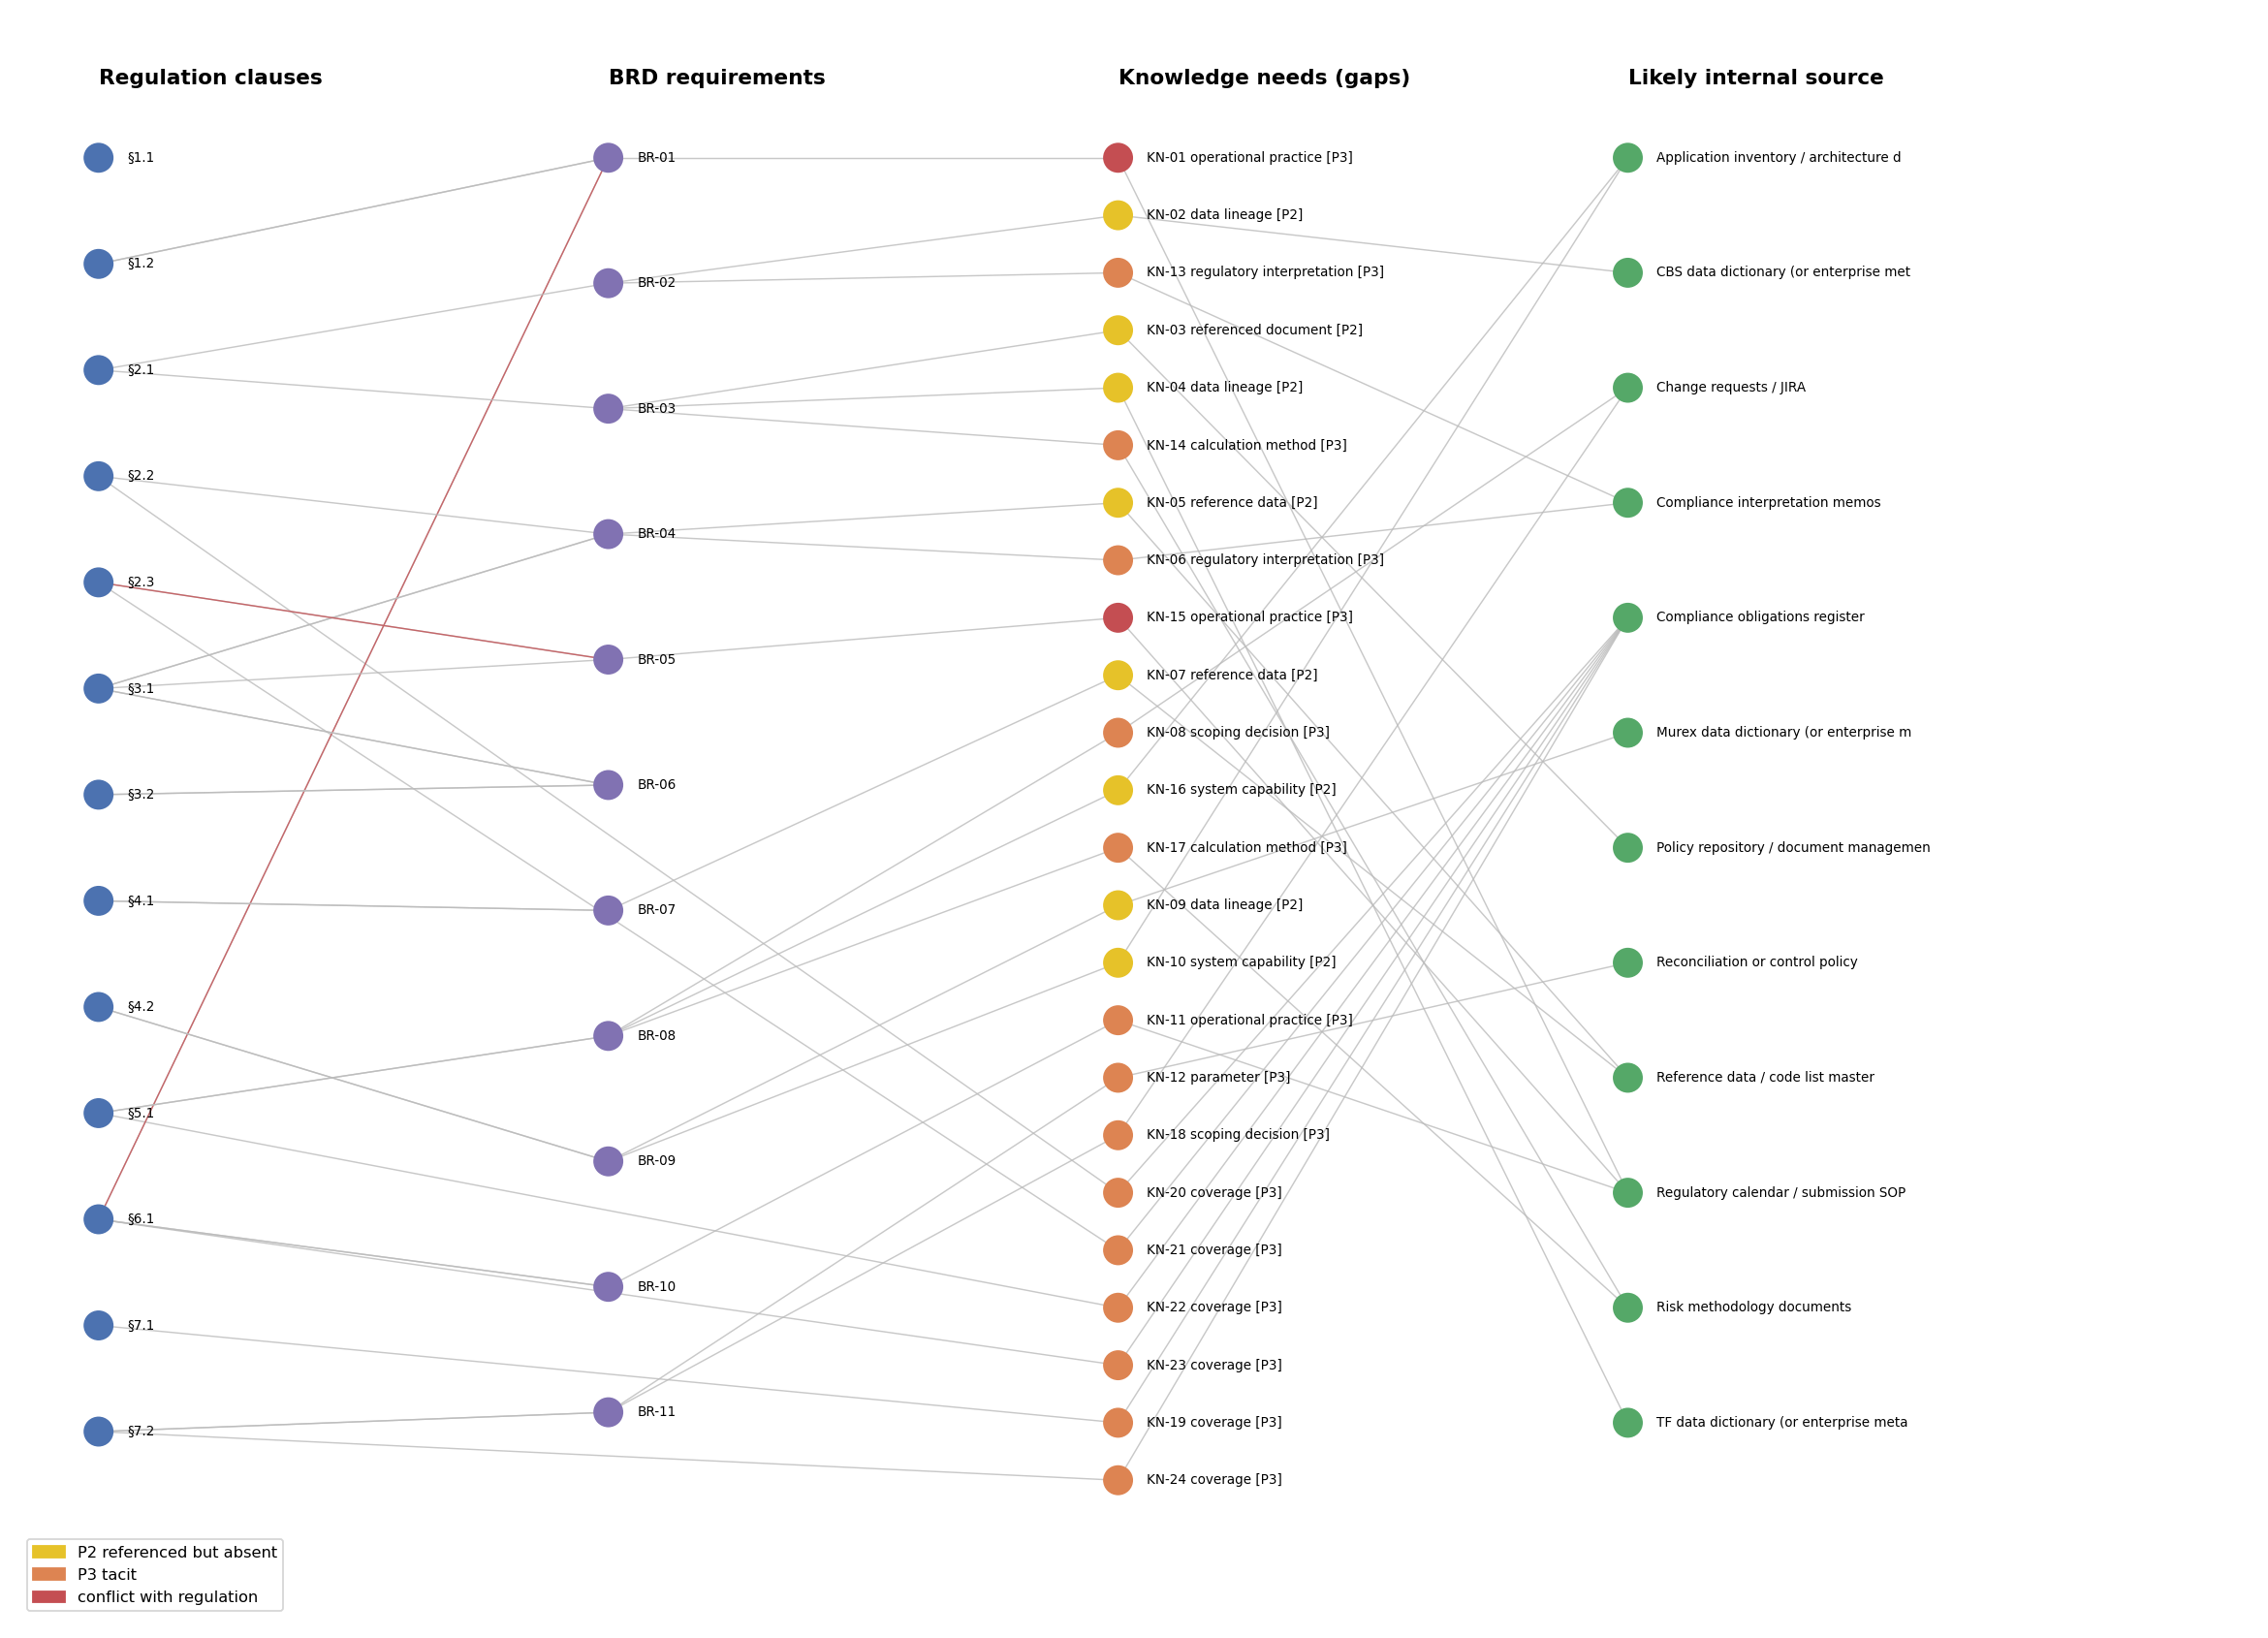

In [10]:
display(Image("outputs/knowledge_graph.png", width=900))

## 8. Does it work on something new?

A quick check that the rules aren't hard-coded to the example: a requirement I didn't use while building them.

In [11]:
from regkg.parse import Requirement
new = Requirement("BR-12", "Customer rating", "Exposures shall use RISK_GRADE from the Finacle ratings table, excluding grades below 3.")
table([{"detail": a.text, "kind": a.kind, "found in": a.grounding} for a in extract_anchors(new, clauses, brd.glossary)],
      ["detail", "kind", "found in"])

| detail | kind | found in |
|---|---|---|
| RISK_GRADE | DATA_FIELD | NONE |
| 3 | PARAMETER | NONE |
| Finacle | SYSTEM | NONE |

It flags `RISK_GRADE`, the unknown system `Finacle`, and the unexplained threshold `3`, with no changes to the code.

## Next

Run this on a real regulation and BRD, with a live LLM and someone independent labelling the gaps.